# Supplementary Figure 9

Computational panels A-D: partition DEG-count distributions, functional-theme
representation, prediction agreement across three runs, and the full Task-1
benchmark table.


In [1]:
%matplotlib inline
%config InlineBackend.figure_format = "retina"
from collections.abc import Callable, Mapping, Sequence
from dataclasses import dataclass
from pathlib import Path

import matplotlib as mpl
import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from matplotlib.ticker import PercentFormatter
from scipy.stats import spearmanr

# Locate the repository whether the notebook is run from the repo root or notebook/.
_start = Path.cwd().resolve()
ROOT = next(
    candidate
    for candidate in (_start, *_start.parents)
    if (candidate / "environment.yml").is_file()
)
DATA_DIR = ROOT / "src" / "manuscript_figures" / "figS9"
STYLE = ROOT / "src" / "manuscript_figures" / "style.mplstyle"
if STYLE.is_file():
    plt.style.use(STYLE)
mpl.rcParams.update(
    {
        "figure.facecolor": "white",
        "axes.facecolor": "white",
        "savefig.facecolor": "white",
        "figure.dpi": 150,
        "savefig.dpi": 300,
        "svg.fonttype": "none",
        "pdf.fonttype": 42,
    }
)


In [2]:
TRAINING = pd.read_csv(
    DATA_DIR / "a" / "analysis" / "151_TH_Prkcd_Grin2c_Glut_deg_counts_training.csv"
)
HOLDOUT = pd.read_csv(
    DATA_DIR / "a" / "analysis" / "151_TH_Prkcd_Grin2c_Glut_deg_counts_holdouts.csv"
)
THEMES = pd.read_csv(DATA_DIR / "b" / "analysis" / "functional_theme_summary.csv")
REPLICATES = pd.read_csv(
    DATA_DIR / "c" / "analysis" / "distributed_agents_3x_merged.tsv", sep="\t"
)
TASK1 = pd.read_csv(DATA_DIR / "d" / "analysis" / "task1_deg_count_comparison.csv")

assert len(TRAINING) == 1_674 and TRAINING["target_name"].is_unique
assert len(HOLDOUT) == 272 and HOLDOUT["target_name"].is_unique
assert set(TRAINING["target_name"]).isdisjoint(HOLDOUT["target_name"])
assert len(REPLICATES) == 272 and REPLICATES["target_name"].is_unique
assert (
    REPLICATES[["original_bioagents", "toolbox_rep_1", "toolbox_rep_2"]].to_numpy() >= 0
).all()


## Supplementary Figure 9A

Observed DEG-count distributions in the 1,674-target training partition and
272-target held-out partition. Percentages are calculated within partition.


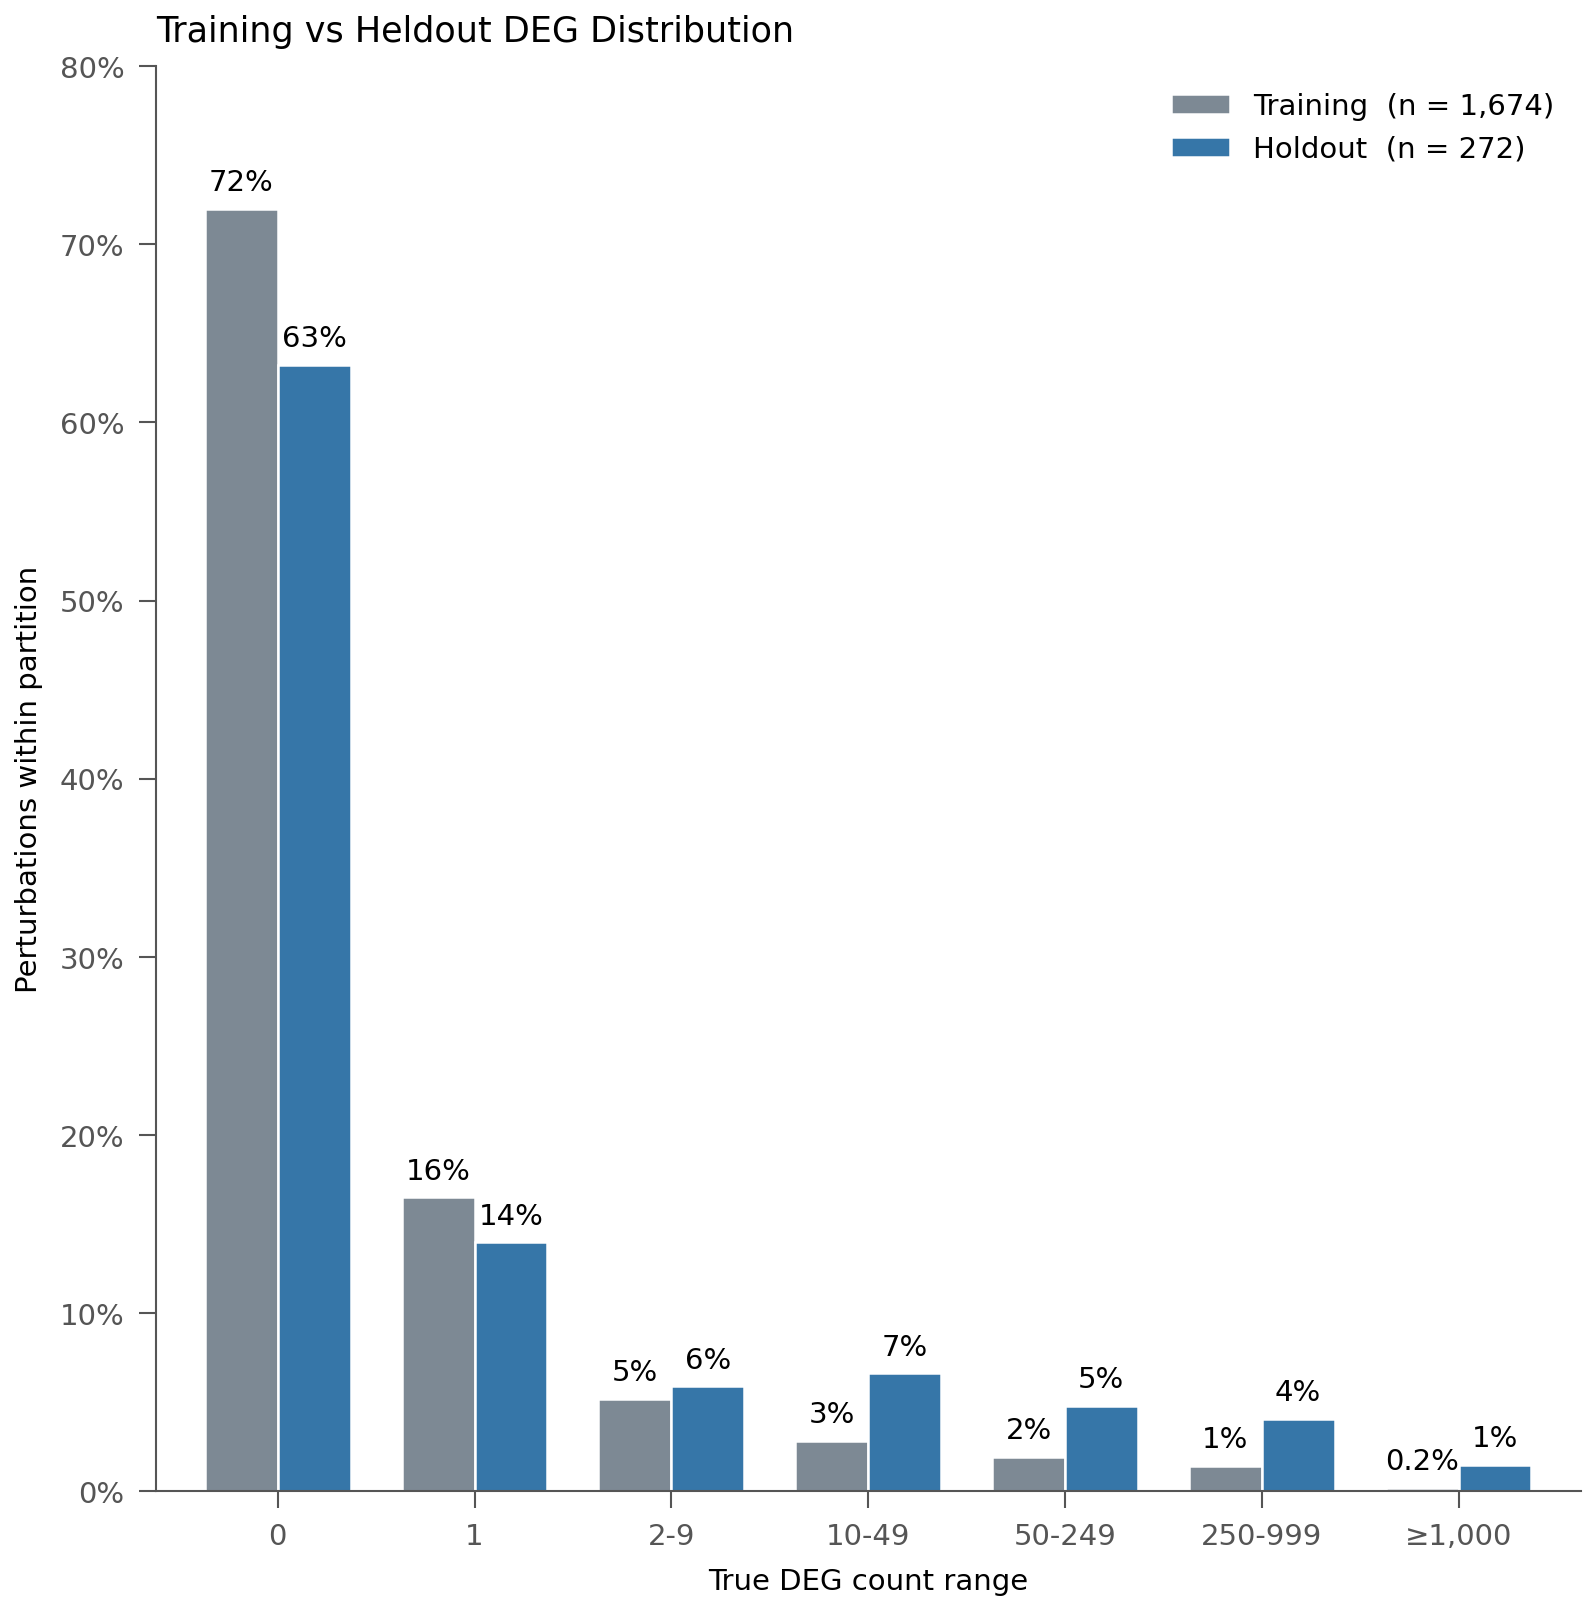

In [3]:
COLORS = {"Training": "#7D8994", "Holdout": "#3676A8"}
COUNT_RANGES = (
    ("0", 0, 0),
    ("1", 1, 1),
    ("2-9", 2, 9),
    ("10-49", 10, 49),
    ("50-249", 50, 249),
    ("250-999", 250, 999),
    ("≥1,000", 1000, np.inf),
)

def bin_counts(values):
    values = np.asarray(values, dtype=int)
    return np.asarray(
        [np.sum((values >= lower) & (values <= upper)) for _, lower, upper in COUNT_RANGES],
        dtype=int,
    )

counts = {
    "Training": bin_counts(TRAINING["n_degs"]),
    "Holdout": bin_counts(HOLDOUT["n_degs"]),
}
sizes = {"Training": len(TRAINING), "Holdout": len(HOLDOUT)}
assert counts["Training"].tolist() == [1205, 276, 87, 47, 32, 24, 3]
assert counts["Holdout"].tolist() == [172, 38, 16, 18, 13, 11, 4]

fig_a, ax = plt.subplots(figsize=(7.2, 5.5))
x = np.arange(len(COUNT_RANGES), dtype=float)
width = 0.37
for label, offset in (("Training", -width / 2), ("Holdout", width / 2)):
    proportions = counts[label] / sizes[label]
    bars = ax.bar(
        x + offset,
        proportions,
        width=width,
        color=COLORS[label],
        edgecolor="white",
        linewidth=0.6,
        label=f"{label}  (n = {sizes[label]:,})",
    )
    ax.bar_label(
        bars,
        labels=[f"{value:.0%}" if value >= 0.01 else f"{value:.1%}" for value in proportions],
        padding=3,
        fontsize=7,
    )
ax.set_xticks(x, [label for label, _, _ in COUNT_RANGES])
ax.set_xlim(-0.62, len(COUNT_RANGES) - 0.38)
ax.set_ylim(0, 0.80)
ax.set_yticks(np.arange(0, 0.81, 0.10))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=1, decimals=0))
ax.set_xlabel("True DEG count range")
ax.set_ylabel("Perturbations within partition")
ax.set_title("Training vs Heldout DEG Distribution", loc="left")
ax.legend(loc="upper right", frameon=False)
ax.set_box_aspect(1)
fig_a.tight_layout(pad=1.1)
fig_a;


## Supplementary Figure 9B

Representation of 14 overlapping functional themes in the training and held-out partitions.

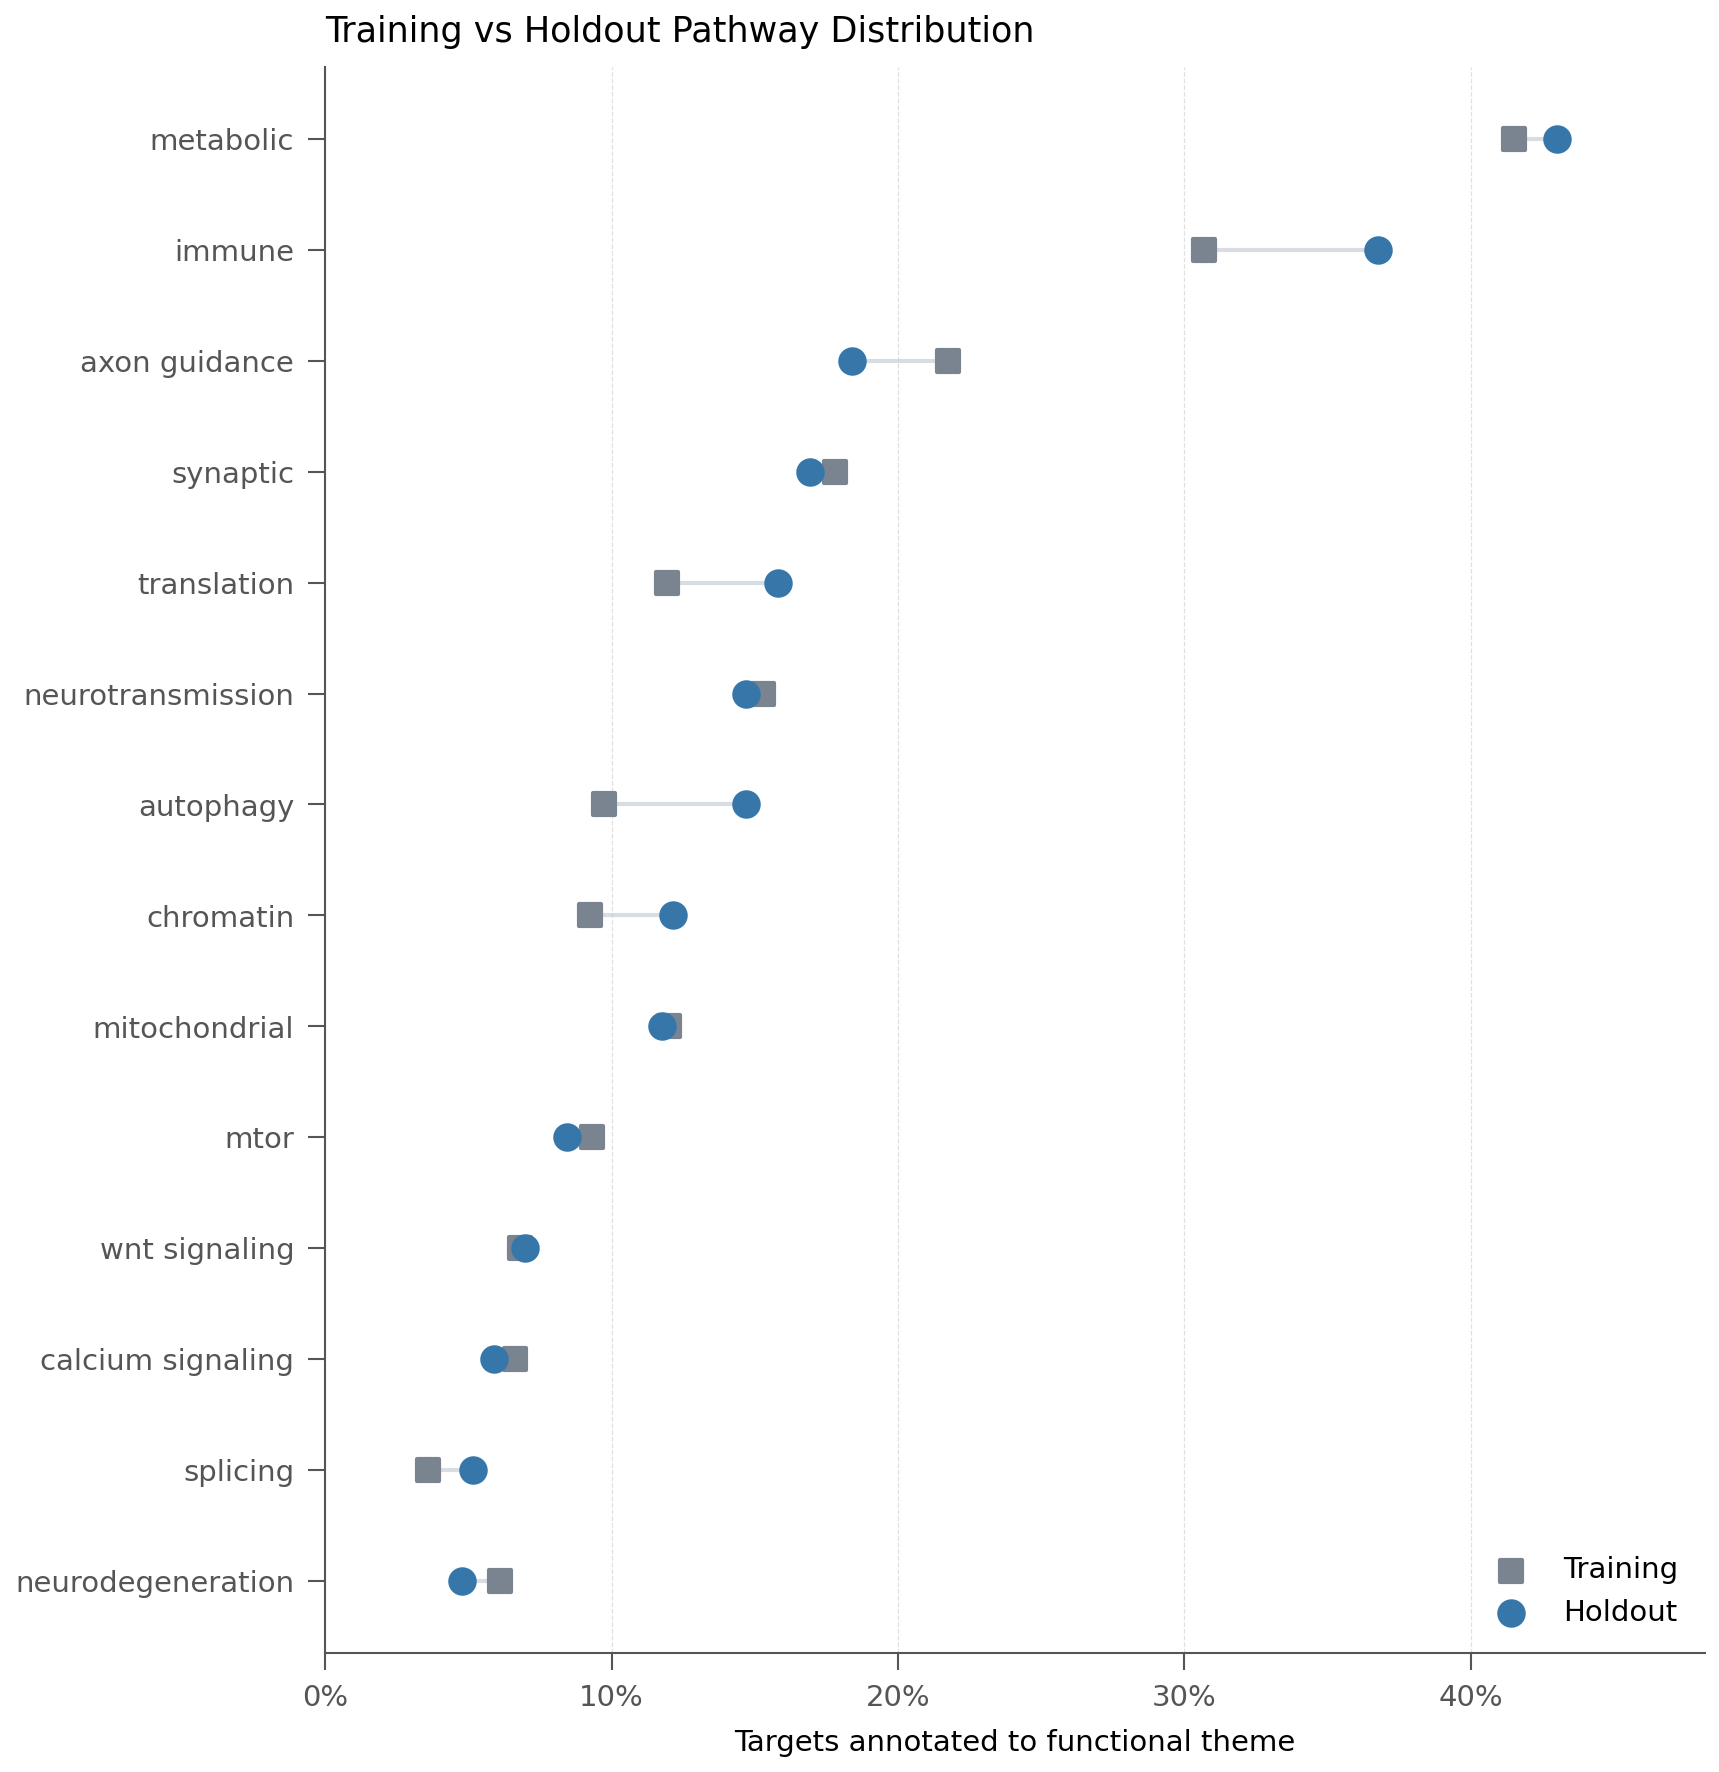

In [4]:
GROUP_COLORS = {"training": "#7A8490", "holdout": "#3676A8"}
selected = THEMES[THEMES["comparison"].eq("holdout_vs_training")].copy()
selected = selected.sort_values(
    ["query_fraction", "reference_fraction"], ascending=[True, True]
).reset_index(drop=True)
y = np.arange(len(selected))

fig_b, ax = plt.subplots(figsize=(5.7, 6.2))
for position, row in enumerate(selected.itertuples(index=False)):
    ax.plot(
        [row.reference_fraction, row.query_fraction],
        [position, position],
        color="#D8DDE3",
        linewidth=1.0,
        zorder=1,
    )
ax.scatter(
    selected["reference_fraction"],
    y,
    s=30,
    color=GROUP_COLORS["training"],
    marker="s",
    clip_on=False,
    label="Training",
    zorder=2,
)
ax.scatter(
    selected["query_fraction"],
    y,
    s=34,
    color=GROUP_COLORS["holdout"],
    marker="o",
    clip_on=False,
    label="Holdout",
    zorder=3,
)
ax.set_yticks(y, [theme.replace("_", " ") for theme in selected["theme"]])
ax.set_xlim(
    0,
    float(selected[["query_fraction", "reference_fraction"]].max().max()) * 1.12,
)
ax.xaxis.set_major_formatter(PercentFormatter(1.0, decimals=0))
ax.set_xlabel("Targets annotated to functional theme")
ax.set_title("Training vs Holdout Pathway Distribution", loc="left")
ax.grid(axis="x")
ax.legend(frameon=False, loc="lower right", fontsize=7)
ax.set_box_aspect(1.15)
fig_b.tight_layout(pad=1.0)
fig_b;


## Supplementary Figure 9C

Spearman correlation among three prediction runs over the same 272 held-out targets.

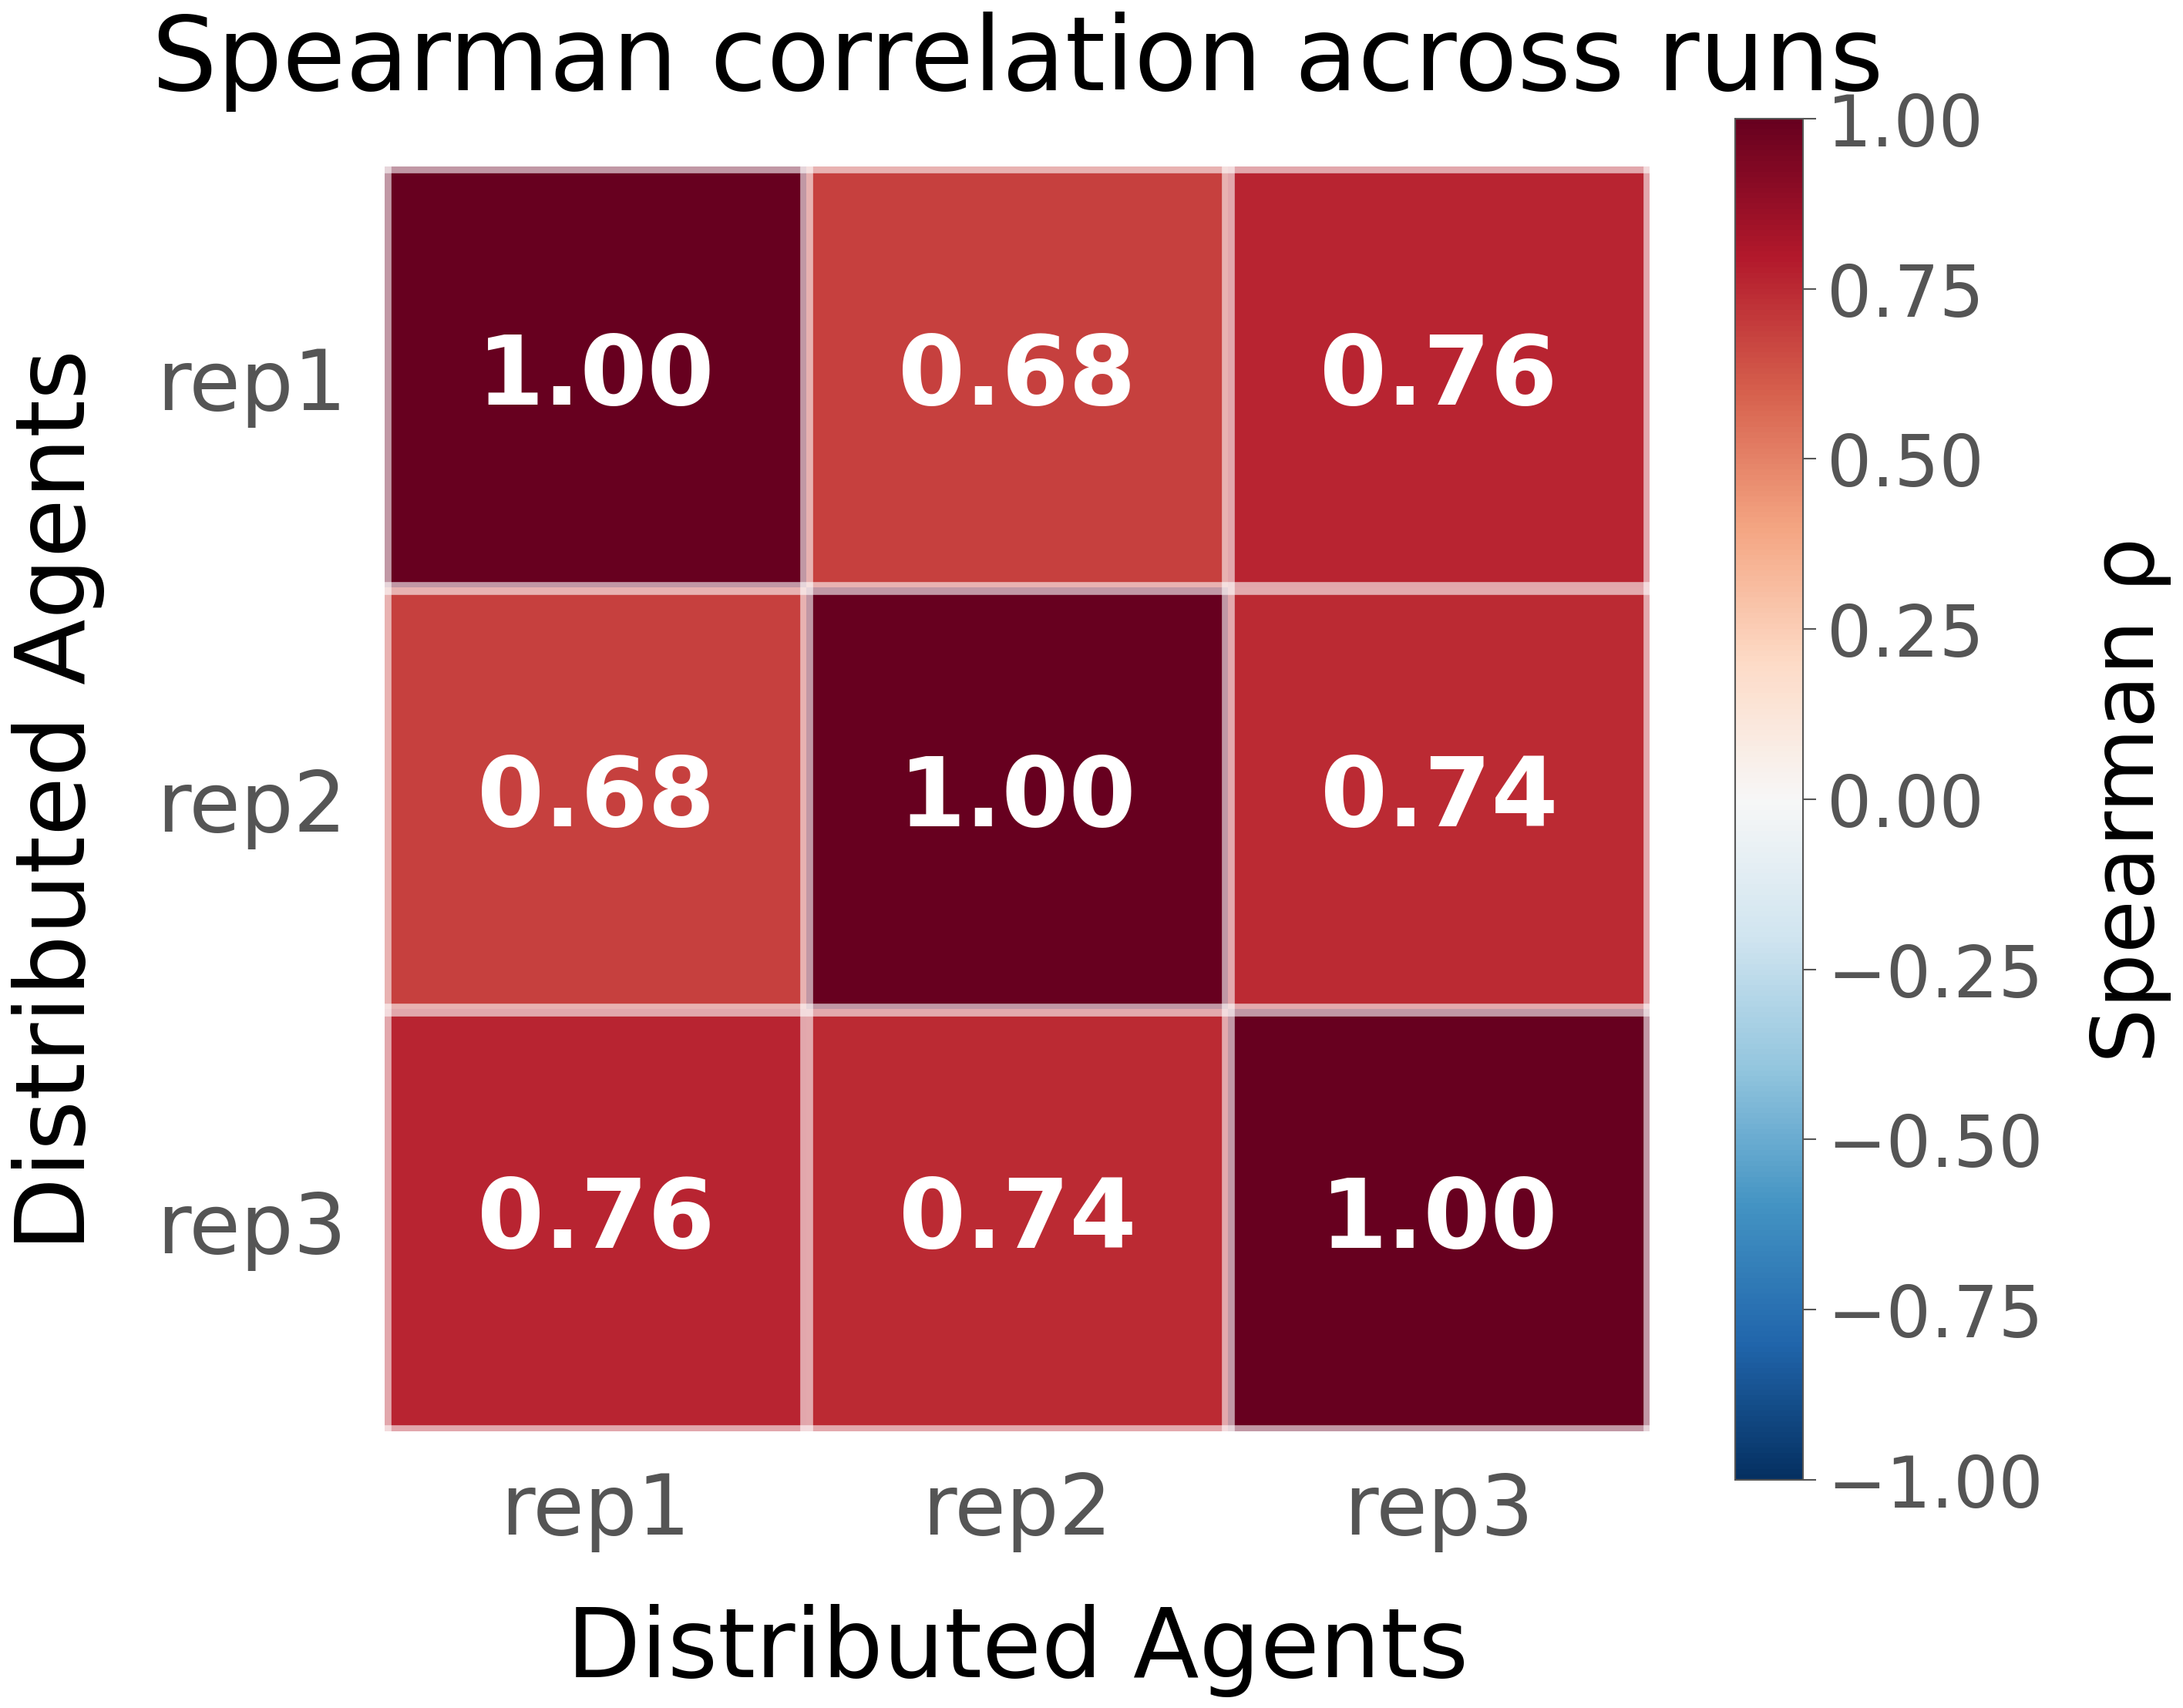

In [5]:
PREDICTION_COLUMNS = ["original_bioagents", "toolbox_rep_1", "toolbox_rep_2"]
RUN_LABELS = ["rep1", "rep2", "rep3"]
predictions = REPLICATES[PREDICTION_COLUMNS].to_numpy(dtype=float)
matrix = np.asarray(spearmanr(predictions, axis=0).statistic, dtype=float)
if matrix.shape != (3, 3):
    raise ValueError(f"Expected a 3x3 correlation matrix, found {matrix.shape}")

fig_c, ax = plt.subplots(figsize=(9.5, 8.5))
image = ax.imshow(matrix, cmap="RdBu_r", vmin=-1, vmax=1, interpolation="nearest")

ax.set_xticks(range(3), RUN_LABELS, fontsize=26)
ax.set_yticks(range(3), RUN_LABELS, fontsize=26)
ax.set_xlabel("Distributed Agents", fontsize=30, labelpad=16)
ax.set_ylabel("Distributed Agents", fontsize=30, labelpad=16)
ax.set_title("Spearman correlation across runs", fontsize=32, pad=24)

for row in range(3):
    for column in range(3):
        ax.text(
            column,
            row,
            f"{matrix[row, column]:.2f}",
            ha="center",
            va="center",
            fontsize=30,
            fontweight="bold",
            color="white" if matrix[row, column] >= 0.55 else "black",
        )

ax.set_xticks(np.arange(-0.5, 3, 1), minor=True)
ax.set_yticks(np.arange(-0.5, 3, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=4, linestyle="-")
ax.tick_params(which="minor", bottom=False, left=False)
ax.tick_params(axis="both", length=0, pad=12)
for spine in ax.spines.values():
    spine.set_visible(False)

colorbar = fig_c.colorbar(image, ax=ax, fraction=0.048, pad=0.06)
colorbar.set_label("Spearman ρ", fontsize=27, labelpad=14)
colorbar.ax.tick_params(labelsize=22)
fig_c.tight_layout()
fig_c;


## Supplementary Figure 9D

Classification, count-prediction, and confusion-matrix metrics across benchmark conditions.

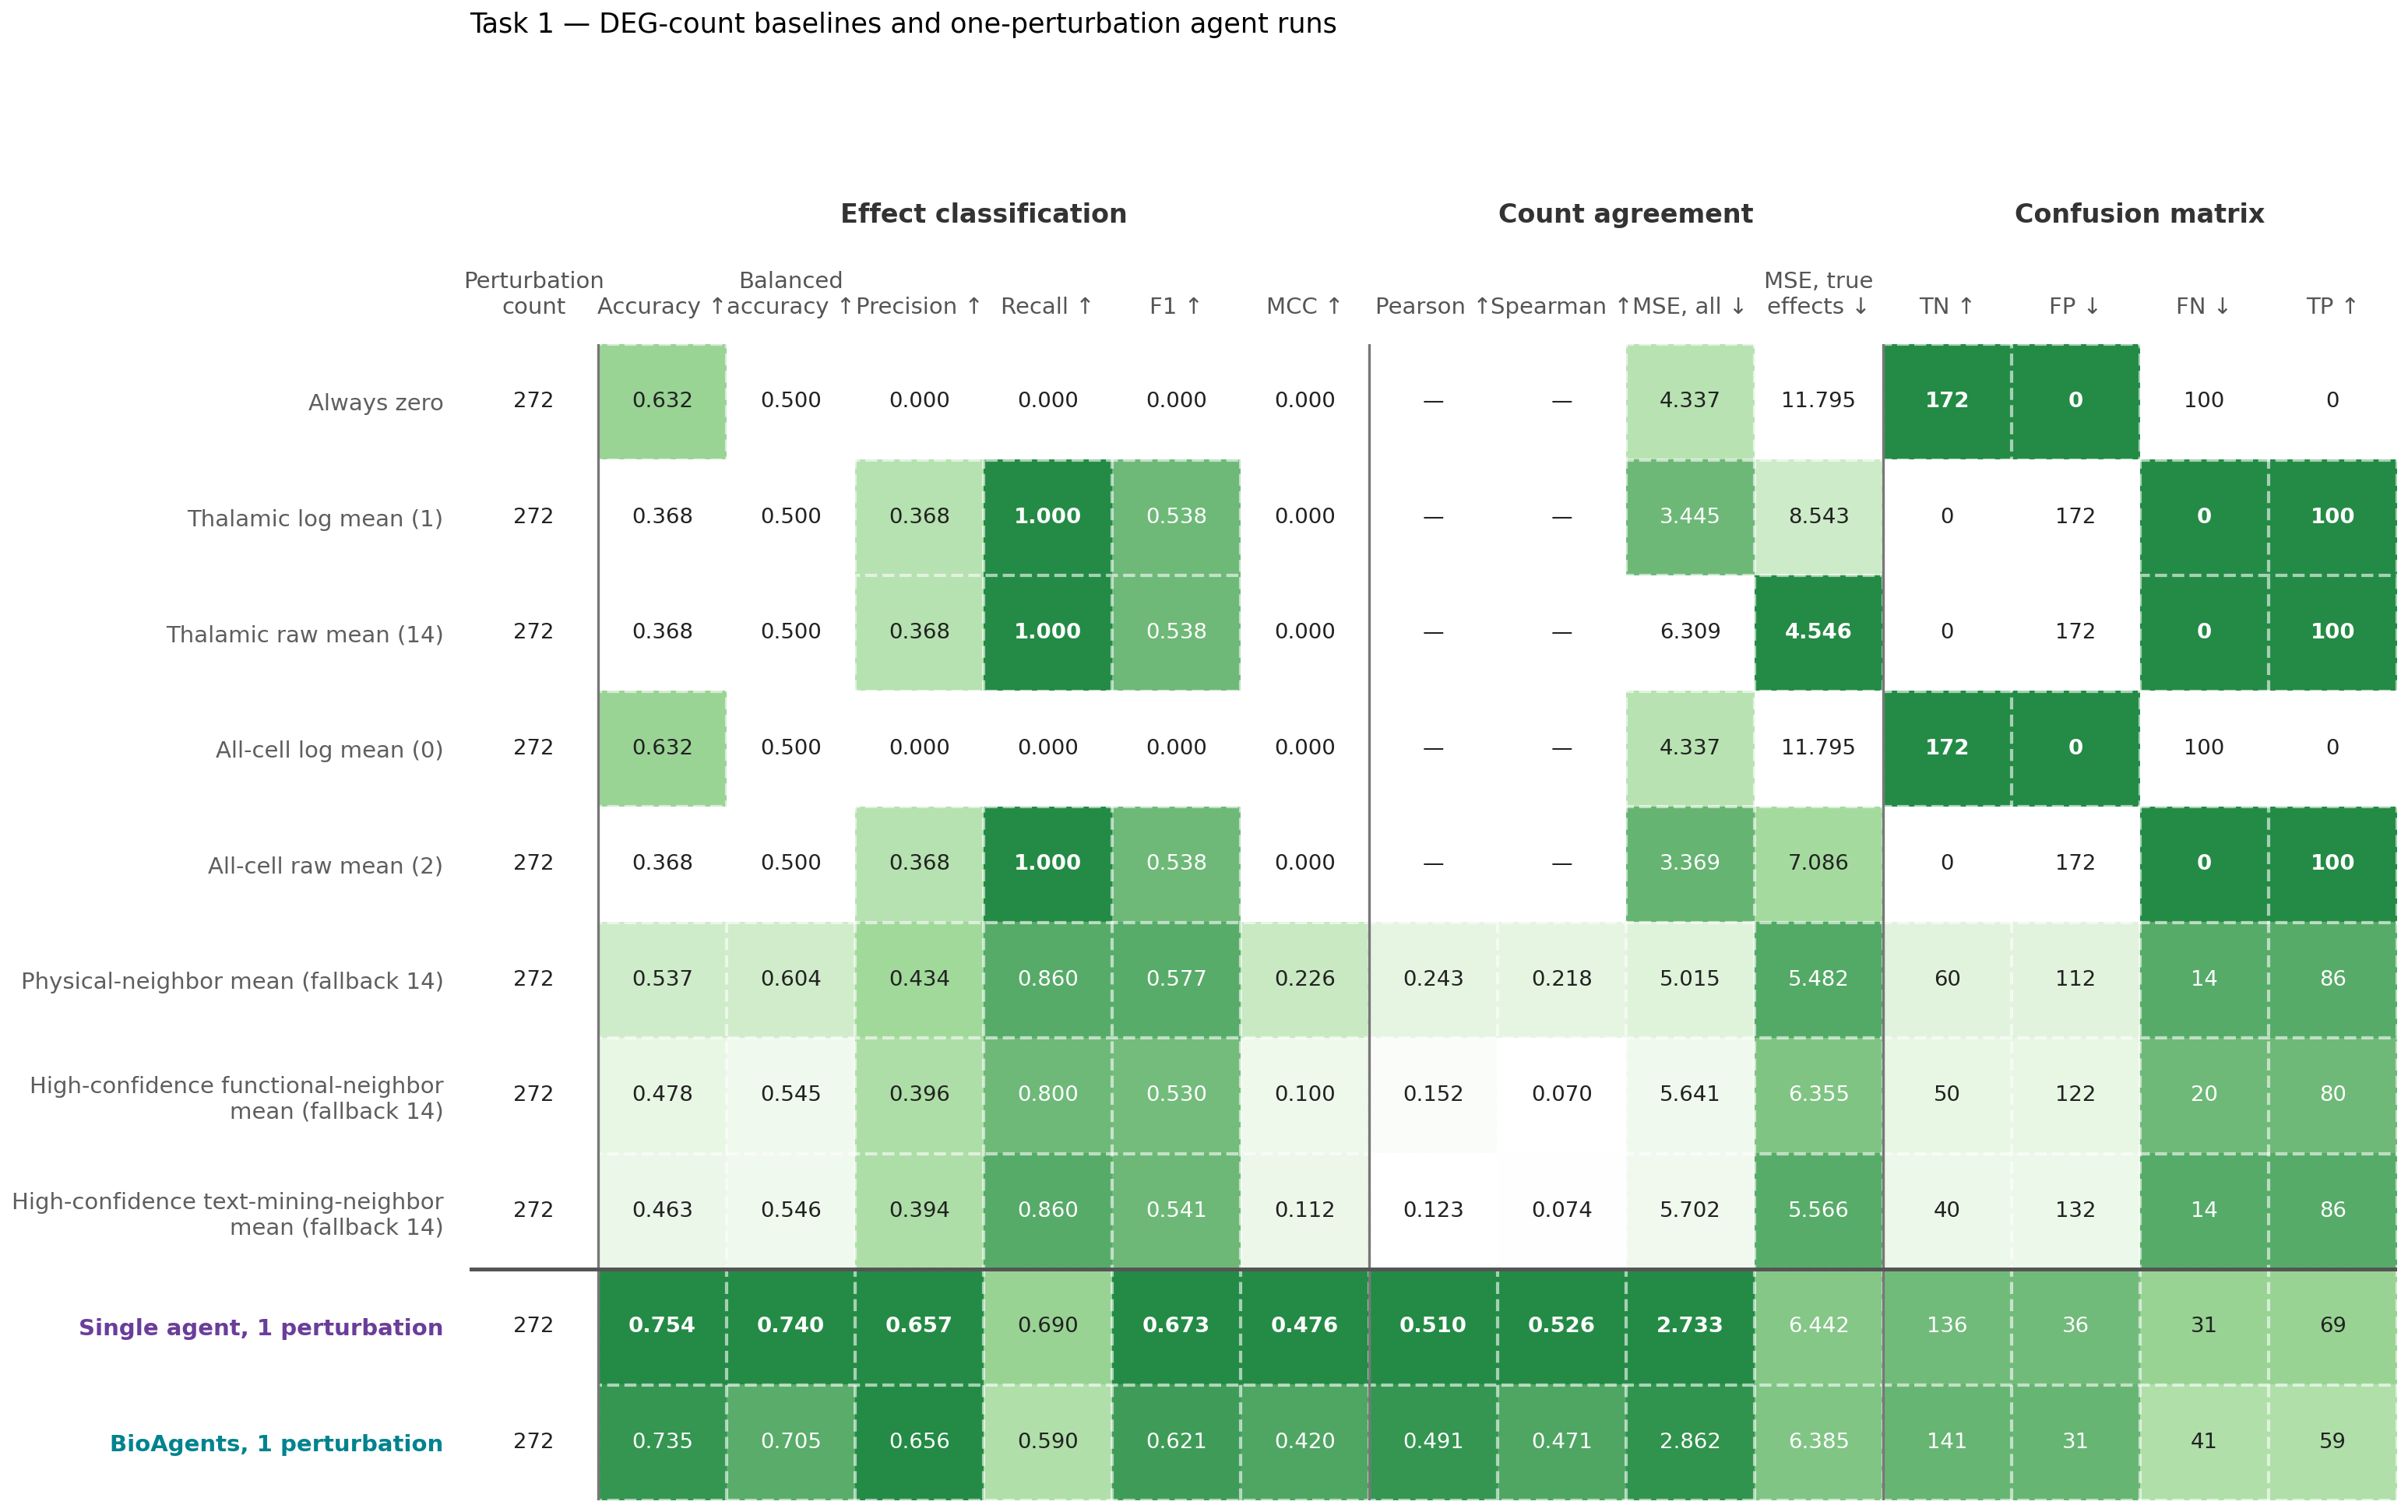

In [6]:
ROW_COLORS = {
    "baseline": "#5e5e5e",
    "single agent": "#6a3d9a",
    "BioAgents": "#00838f",
}
QUALITY_CMAP = mcolors.LinearSegmentedColormap.from_list(
    "table_quality", ("#ffffff", "#e5f5e0", "#a1d99b", "#238b45")
)

@dataclass(frozen=True)
class Metric:
    key: str
    label: str
    group: str
    direction: str | None
    formatter: Callable[[float], str]

def decimal(value):
    return f"{value:.3f}"

def integer(value):
    return f"{value:,.0f}"

METRICS = (
    Metric("n_targets", "Perturbation\ncount", "N", None, integer),
    Metric("accuracy", "Accuracy ↑", "Effect classification", "high", decimal),
    Metric("balanced_accuracy", "Balanced\naccuracy ↑", "Effect classification", "high", decimal),
    Metric("precision", "Precision ↑", "Effect classification", "high", decimal),
    Metric("recall", "Recall ↑", "Effect classification", "high", decimal),
    Metric("f1", "F1 ↑", "Effect classification", "high", decimal),
    Metric("matthews_correlation", "MCC ↑", "Effect classification", "high", decimal),
    Metric("pearson_log1p", "Pearson ↑", "Count agreement", "high", decimal),
    Metric("spearman_log1p", "Spearman ↑", "Count agreement", "high", decimal),
    Metric("mse_log1p_all", "MSE, all ↓", "Count agreement", "low", decimal),
    Metric("mse_log1p_true_effect", "MSE, true\neffects ↓", "Count agreement", "low", decimal),
    Metric("true_negative", "TN ↑", "Confusion matrix", "high", integer),
    Metric("false_positive", "FP ↓", "Confusion matrix", "low", integer),
    Metric("false_negative", "FN ↓", "Confusion matrix", "low", integer),
    Metric("true_positive", "TP ↑", "Confusion matrix", "high", integer),
)
LABELS = {
    "always_zero": "Always zero",
    "constant_log_mse": "Thalamic log mean (1)",
    "constant_arithmetic_mean": "Thalamic raw mean (14)",
    "all_cell_types_constant_log_mse": "All-cell log mean (0)",
    "all_cell_types_constant_arithmetic_mean": "All-cell raw mean (2)",
    "physical_neighbor_mean_count": "Physical-neighbor mean (fallback 14)",
    "functional_neighbor_mean_count": "High-confidence functional-neighbor\nmean (fallback 14)",
    "literature_neighbor_mean_count": "High-confidence text-mining-neighbor\nmean (fallback 14)",
}

batch_one = pd.to_numeric(TASK1["batch_size"], errors="coerce").eq(1)
selected_rows = TASK1[TASK1["system"].eq("baseline") | batch_one].copy()
assert len(selected_rows) == 10
rows = selected_rows.to_dict("records")

def row_label(row):
    if row["system"] == "baseline":
        return LABELS[row["method"]]
    if row["system"] == "for_alex_single_agent":
        return "Single agent, 1 perturbation"
    return "BioAgents, 1 perturbation"

def row_concept(row):
    if row["system"] == "baseline":
        return "baseline"
    if row["system"] == "for_alex_single_agent":
        return "single agent"
    return "BioAgents"

table_values = np.full((len(rows), len(METRICS)), np.nan)
for row_index, row in enumerate(rows):
    for column_index, metric in enumerate(METRICS):
        raw = row[metric.key]
        if pd.notna(raw):
            table_values[row_index, column_index] = float(raw)

quality = np.full_like(table_values, np.nan)
for column_index, metric in enumerate(METRICS):
    column = table_values[:, column_index]
    finite = np.isfinite(column)
    if metric.direction is None or not finite.any():
        continue
    low, high = np.min(column[finite]), np.max(column[finite])
    scaled = (
        (column[finite] - low) / (high - low)
        if high != low
        else np.full(finite.sum(), 0.25)
    )
    quality[finite, column_index] = scaled if metric.direction == "high" else 1 - scaled

spans = []
start = 0
for index in range(1, len(METRICS) + 1):
    if index == len(METRICS) or METRICS[index].group != METRICS[start].group:
        spans.append((METRICS[start].group, start, index - 1))
        start = index

fig_d, ax = plt.subplots(figsize=(19.5, 7.5))
masked = np.ma.masked_invalid(quality)
cmap = QUALITY_CMAP.copy()
cmap.set_bad("white")
ax.imshow(masked, cmap=cmap, vmin=0, vmax=1, aspect="auto", zorder=0)
ax.set_yticks(np.arange(len(rows)), [row_label(row) for row in rows])
ax.set_xticks(np.arange(len(METRICS)), [metric.label for metric in METRICS])
ax.tick_params(
    axis="x", top=True, bottom=False, labeltop=True, labelbottom=False, length=0, pad=8
)
ax.tick_params(axis="y", length=0, pad=8)
for tick, row in zip(ax.get_yticklabels(), rows, strict=True):
    tick.set_color(ROW_COLORS[row_concept(row)])
    if row["system"] != "baseline":
        tick.set_fontweight("bold")
for row_index in range(len(rows)):
    for column_index, metric in enumerate(METRICS):
        value = table_values[row_index, column_index]
        label = "—" if not np.isfinite(value) else metric.formatter(value)
        cell_quality = quality[row_index, column_index]
        dark = np.isfinite(cell_quality) and cell_quality > 0.72
        best = np.isfinite(cell_quality) and np.isclose(cell_quality, 1.0)
        ax.text(
            column_index,
            row_index,
            label,
            ha="center",
            va="center",
            color="white" if dark else "#222222",
            fontweight="bold" if best else "normal",
            fontsize=6.6,
            zorder=2,
        )
ax.set_xticks(np.arange(-0.5, len(METRICS), 1), minor=True)
ax.set_yticks(np.arange(-0.5, len(rows), 1), minor=True)
ax.grid(which="minor", color="white", linewidth=1.0)
ax.tick_params(which="minor", bottom=False, left=False)
for group, first, last in spans:
    center = (first + last) / 2
    if group != "N":
        ax.text(
            center,
            1.10,
            group,
            transform=ax.get_xaxis_transform(),
            ha="center",
            va="bottom",
            fontweight="bold",
            fontsize=8,
            color="#333333",
            clip_on=False,
        )
    if last < len(METRICS) - 1:
        ax.axvline(last + 0.5, color="#777777", linewidth=0.8, zorder=3)
ax.axhline(7.5, color="#555555", linewidth=1.2, zorder=3)
ax.set_xlim(-0.5, len(METRICS) - 0.5)
ax.set_ylim(len(rows) - 0.5, -0.5)
ax.set_title("Task 1 — DEG-count baselines and one-perturbation agent runs", loc="left", pad=96)
ax.set_box_aspect(0.60)
for spine in ax.spines.values():
    spine.set_visible(False)
fig_d.subplots_adjust(left=0.16, right=0.995, top=0.76, bottom=0.10)
fig_d;
